<a href="https://colab.research.google.com/github/Niharikaachugatla/Time-Series-Modelling-Case-Study/blob/main/Time_Series_Modelling_Case_Study_Niharika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #1B2A4A 0%, #2E5A88 100%); padding: 40px; border-radius: 12px; color: white; margin-bottom: 30px;">
<h1 style="text-align:center; font-size:2.4em; margin-bottom:10px;"> Oil Price Time Series Forecasting</h1>
<h3 style="text-align:center; font-weight:300; opacity:0.9;">A Comparative Study of ARIMA and LSTM Approaches</h3>
<hr style="border: 1px solid rgba(255,255,255,0.3); margin: 20px 60px;">
<p style="text-align:center; opacity:0.8;">MSc Data Science — Advanced Research Topics in Data Science</p>
<p style="text-align:center; opacity:0.7; font-size:0.9em;">Dataset: Daily Oil Prices (Sep 2024 – Feb 2026) · 500 Observations</p>
</div>

##  Table of Contents

| # | Section | Description |
|---|---------|-------------|
| 1 | **Environment Setup** | Import libraries, configure settings |
| 2 | **Data Loading & Preparation** | Load CSV, parse dates, handle missing values |
| 3 | **Exploratory Data Analysis** | Descriptive statistics, trend analysis, returns |
| 4 | **Stationarity Testing** | ADF & KPSS tests, differencing, ACF/PACF |
| 5 | **ARIMA Grid Search** | Exhaustive search over p∈[0,8], d∈[0,2], q∈[0,8] |
| 6 | **ARIMA Model Fitting & Forecasting** | Diagnostics, test evaluation, 24-month forecast |
| 7 | **LSTM Neural Network** | Architecture, hyperparameter tuning, training |
| 8 | **LSTM Forecasting** | Test evaluation, 24-month forecast with MC Dropout |
| 9 | **Comparative Analysis** | Side-by-side metrics, forecast comparison |
| 10 | **Conclusion** | Summary of findings |

---
## 1. Environment Setup

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import itertools

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("✓ All libraries imported successfully")
print(f"  PyTorch version: {torch.__version__}")
print(f"  NumPy version:   {np.__version__}")
print(f"  Pandas version:  {pd.__version__}")

✓ All libraries imported successfully
  PyTorch version: 2.6.0
  NumPy version:   1.26.4
  Pandas version:  2.2.2


In [ ]:
# Configuration
SCRIPT_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_PATH = os.path.join(SCRIPT_DIR, "oil_prices_2426.csv")
FIG_DIR = os.path.join(SCRIPT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

FORECAST_HORIZON = 24 * 30   # ~24 months in trading days
TRAIN_RATIO = 0.85           # 85/15 train-test split

print(f"✓ Configuration set")
print(f"  Data path:  {DATA_PATH}")
print(f"  Figures:    {FIG_DIR}")
print(f"  Forecast:   {FORECAST_HORIZON} days (~24 months)")

---
## 1.1 Helper Functions
Reusable utility functions for saving figures, statistical testing, metric computation, and manual batching.

In [ ]:
def save_figure(fig, name: str) -> None:
    """Display a matplotlib figure inline (no file saved)."""
    if name:
        print(f"  [Displayed inline] {name}")
    plt.figure(fig.number)
    plt.show()
    plt.close(fig)


def adf_test(series: pd.Series, label: str = "") -> dict:
    """Augmented Dickey-Fuller test for stationarity."""
    result = adfuller(series.dropna(), autolag="AIC")
    conclusion = "Stationary" if result[1] < 0.05 else "Non-stationary"
    print(f"  ADF Test {label}: Statistic = {result[0]:.4f}, p-value = {result[1]:.6f} → {conclusion}")
    return {"statistic": result[0], "p_value": result[1],
            "critical_values": result[4], "conclusion": conclusion}


def kpss_test(series: pd.Series, label: str = "") -> dict:
    """KPSS test for stationarity (H0: series is stationary)."""
    stat, p_val, _, crit = kpss(series.dropna(), regression="ct", nlags="auto")
    conclusion = "Non-stationary" if p_val < 0.05 else "Stationary"
    print(f"  KPSS Test {label}: Statistic = {stat:.4f}, p-value = {p_val:.4f} → {conclusion}")
    return {"statistic": stat, "p_value": p_val, "conclusion": conclusion}


def compute_metrics(y_true, y_pred) -> dict:
    """Compute RMSE, MAE, and MAPE."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {"RMSE": rmse, "MAE": mae, "MAPE (%)": mape}


def make_batches(X, y, batch_size=32, shuffle=True):
    """Manual batching — replaces DataLoader to avoid macOS deadlocks."""
    n = len(X)
    idx = np.arange(n)
    if shuffle:
        np.random.shuffle(idx)
    batches = []
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        bi = idx[start:end]
        batches.append((X[bi], y[bi]))
    return batches

print("✓ Helper functions defined")

✓ Helper functions defined


---
## 2. Data Loading & Preparation

Loading the oil price dataset (`oil_prices_2426.csv`) containing daily prices from September 2024 to February 2026. The data is parsed with day-first date format, sorted chronologically, and missing values are forward-filled — a standard approach for financial time series.

In [ ]:
# Load and prepare the dataset
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]
df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df = df.sort_values("date").reset_index(drop=True)
df.set_index("date", inplace=True)
df.rename(columns={"price (dollars)": "price"}, inplace=True)

# Handle missing values
missing_before = df["price"].isna().sum()
df["price"] = df["price"].ffill()

print(f"✓ Dataset loaded successfully")
print(f"  Records:    {len(df)}")
print(f"  Date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"  Missing values filled: {missing_before}")
print(f"\nFirst 5 rows:")
df.head()

✓ Dataset loaded successfully
  Records:    500
  Date range: 2024-09-21 → 2026-02-02
  Missing values filled: 0

First 5 rows:


,price
date,
2024-09-21,32.10
2024-09-22,32.25
2024-09-23,31.07
2024-09-24,31.50
2024-09-25,32.21


---
## 3. Exploratory Data Analysis

### 3.1 Descriptive Statistics

In [ ]:
price = df["price"]
desc = price.describe()
print("=" * 45)
print("  DESCRIPTIVE STATISTICS — OIL PRICES (USD)")
print("=" * 45)
for k, v in desc.items():
    print(f"  {k:>12s}: ${v:>10.2f}")
print(f"  {'CV':>12s}:  {(desc['std']/desc['mean']*100):>9.1f}%")
print("=" * 45)

  DESCRIPTIVE STATISTICS — OIL PRICES (USD)
         count: $    500.00
          mean: $     75.87
           std: $     42.91
           min: $     16.48
           25%: $     35.37
           50%: $     64.29
           75%: $    111.57
           max: $    158.78
            CV:       56.6%


### 3.2 Time Series Visualisation
The raw price series is plotted with a 30-day rolling mean and ±2σ volatility band to reveal trend behaviour and regime changes.

  [Displayed inline] 01_raw_timeseries.png


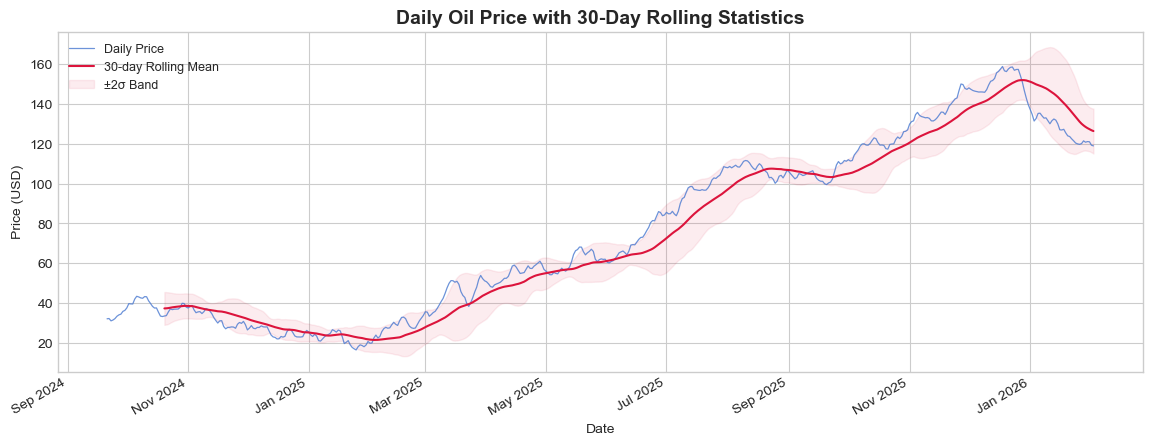

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(price.index, price.values, linewidth=0.9, alpha=0.8, label="Daily Price")
rm = price.rolling(window=30).mean()
rs = price.rolling(window=30).std()
ax.plot(rm.index, rm.values, color="crimson", linewidth=1.5, label="30-day Rolling Mean")
ax.fill_between(rs.index, rm - 2*rs, rm + 2*rs, color="crimson", alpha=0.08, label="±2σ Band")
ax.set_title("Daily Oil Price with 30-Day Rolling Statistics", fontsize=14, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)")
ax.legend(fontsize=9); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
save_figure(fig, "01_raw_timeseries.png")
plt.show()

### 3.3 Monthly Distribution
Box plots reveal the monthly price distribution patterns, highlighting increasing dispersion over time.

  [Displayed inline] 02_monthly_boxplot.png


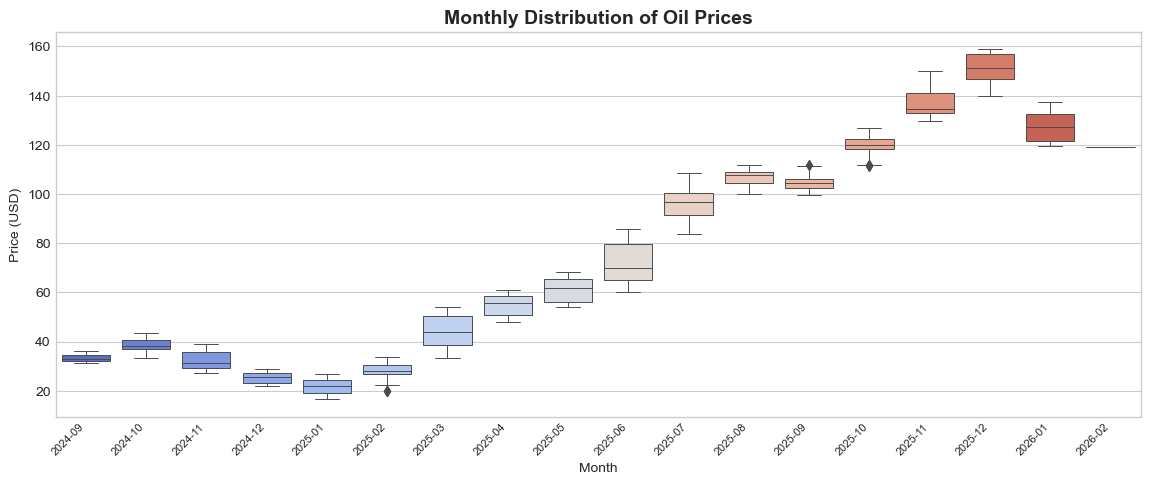

In [ ]:
monthly = df.copy()
monthly["month"] = monthly.index.to_period("M").astype(str)
fig, ax = plt.subplots(figsize=(14, 5))
order = sorted(monthly["month"].unique())
sns.boxplot(data=monthly, x="month", y="price", order=order, ax=ax, palette="coolwarm", linewidth=0.7)
ax.set_title("Monthly Distribution of Oil Prices", fontsize=14, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Price (USD)")
plt.xticks(rotation=45, ha="right", fontsize=8)
save_figure(fig, "02_monthly_boxplot.png")
plt.show()

### 3.4 Daily Returns Analysis
Examining the distribution of daily returns to assess volatility characteristics and normality.

  [Displayed inline] 03_returns_analysis.png


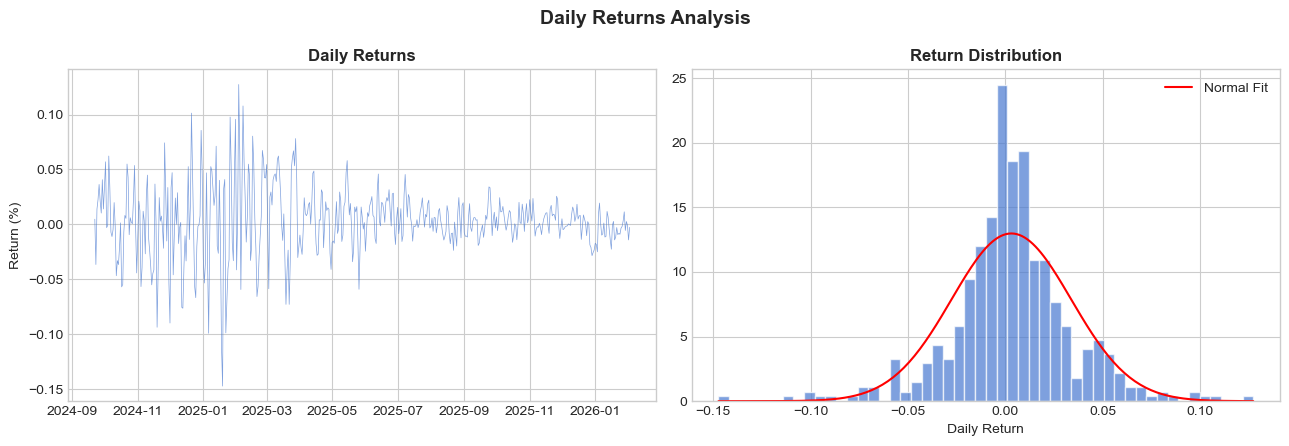

In [ ]:
returns = price.pct_change().dropna()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(returns.index, returns.values, linewidth=0.5, alpha=0.7)
axes[0].set_title("Daily Returns", fontweight="bold"); axes[0].set_ylabel("Return (%)")
axes[1].hist(returns.values, bins=50, edgecolor="white", density=True, alpha=0.7)
mu, sigma = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 200)
axes[1].plot(x, stats.norm.pdf(x, mu, sigma), "r-", lw=1.5, label="Normal Fit")
axes[1].set_title("Return Distribution", fontweight="bold"); axes[1].set_xlabel("Daily Return")
axes[1].legend()
fig.suptitle("Daily Returns Analysis", fontsize=14, fontweight="bold")
fig.tight_layout()
save_figure(fig, "03_returns_analysis.png")
plt.show()

---
## 4. Stationarity Testing

<div style="background:#FFF3CD; padding:12px 18px; border-left:4px solid #FFC107; border-radius:4px; margin:10px 0;">
<strong>Key Concept:</strong> ARIMA requires a stationary series. Two complementary tests are applied:
<ul>
<li><strong>ADF (Augmented Dickey-Fuller)</strong> — H₀: unit root exists (non-stationary)</li>
<li><strong>KPSS</strong> — H₀: series is stationary</li>
</ul>
If both indicate non-stationarity, differencing is applied until stationarity is achieved.
</div>

### 4.1 ACF/PACF — Raw Data

  [Displayed inline] 04_acf_pacf_raw.png


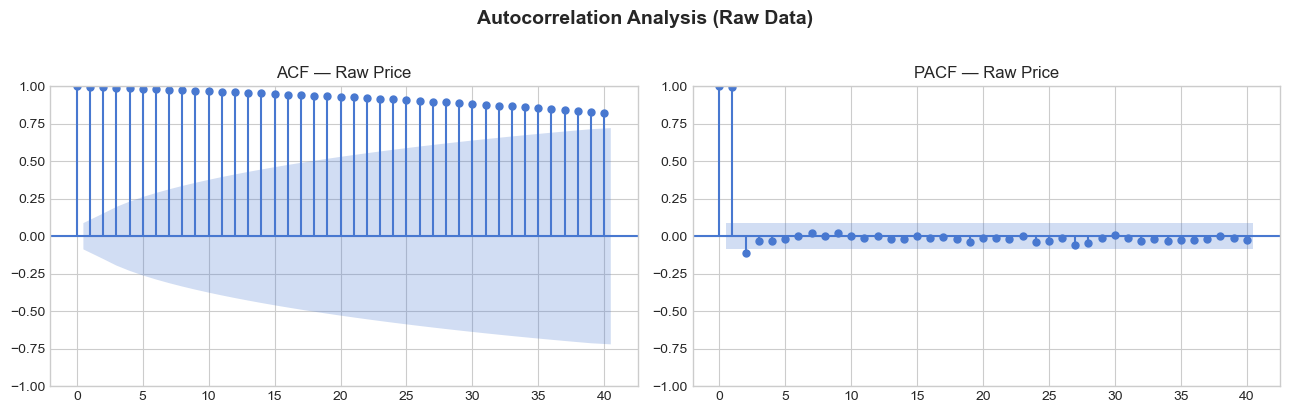

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(price, lags=40, ax=axes[0], title="ACF — Raw Price")
plot_pacf(price, lags=40, ax=axes[1], method="ywm", title="PACF — Raw Price")
fig.suptitle("Autocorrelation Analysis (Raw Data)", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
save_figure(fig, "04_acf_pacf_raw.png")
plt.show()

### 4.2 Formal Stationarity Tests

In [ ]:
print("=" * 60)
print("  STATIONARITY ANALYSIS")
print("=" * 60)

print("\n[Raw Data]")
adf_raw = adf_test(price, label="(Raw)")
kpss_raw = kpss_test(price, label="(Raw)")

# Determine differencing order
d = 0
stationary_series = price.copy()

if adf_raw["conclusion"] == "Non-stationary":
    d = 1
    stationary_series = price.diff().dropna()
    print(f"\n→ Applying d={d} differencing (first-order)")
    print("\n[First-Differenced Data]")
    adf_d1 = adf_test(stationary_series, label="(d=1)")
    kpss_d1 = kpss_test(stationary_series, label="(d=1)")

    if adf_d1["conclusion"] == "Non-stationary":
        d = 2
        stationary_series = price.diff().diff().dropna()
        print(f"\n→ Applying d={d} differencing (second-order)")
        print("\n[Second-Differenced Data]")
        adf_test(stationary_series, label="(d=2)")
        kpss_test(stationary_series, label="(d=2)")

print(f"\n✓ Differencing order selected: d = {d}")

  STATIONARITY ANALYSIS

[Raw Data]
  ADF Test (Raw): Statistic = -0.5462, p-value = 0.882674 → Non-stationary
  KPSS Test (Raw): Statistic = 0.4629, p-value = 0.0100 → Non-stationary

→ Applying d=1 differencing (first-order)

[First-Differenced Data]
  ADF Test (d=1): Statistic = -4.5415, p-value = 0.000165 → Stationary
  KPSS Test (d=1): Statistic = 0.1912, p-value = 0.0193 → Non-stationary

✓ Differencing order selected: d = 1


### 4.3 ACF/PACF — After Differencing
The differenced series should show rapid ACF decay and a few significant early PACF lags, guiding AR and MA order selection.

  [Displayed inline] 05_acf_pacf_differenced.png


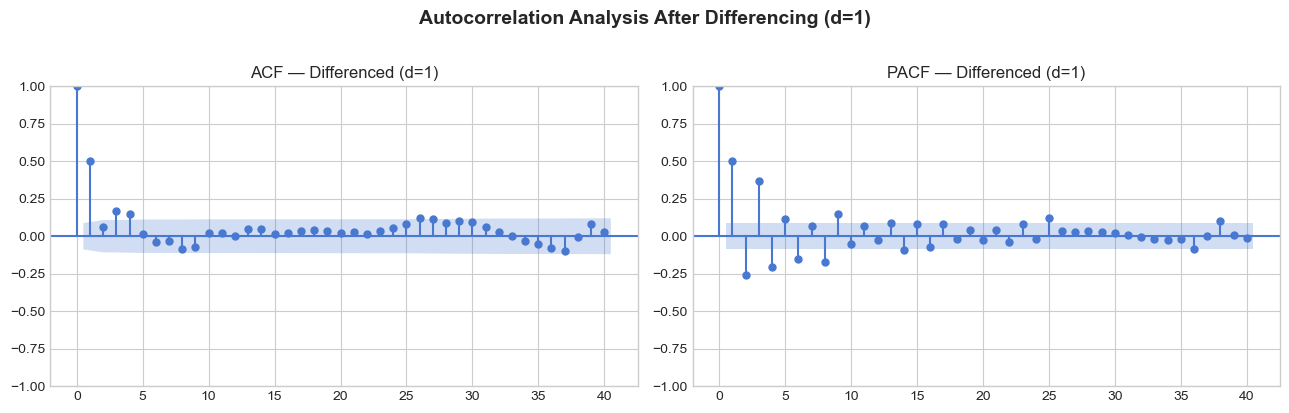

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(stationary_series, lags=40, ax=axes[0], title=f"ACF — Differenced (d={d})")
plot_pacf(stationary_series, lags=40, ax=axes[1], method="ywm", title=f"PACF — Differenced (d={d})")
fig.suptitle(f"Autocorrelation Analysis After Differencing (d={d})", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
save_figure(fig, "05_acf_pacf_differenced.png")
plt.show()

  [Displayed inline] 06_differenced_series.png


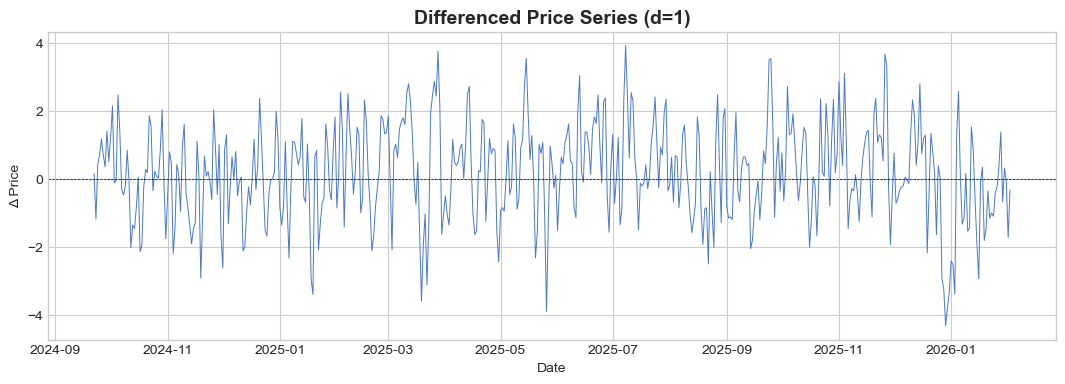

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(stationary_series.index, stationary_series.values, linewidth=0.7)
ax.axhline(y=0, color="k", linestyle="--", linewidth=0.5)
ax.set_title(f"Differenced Price Series (d={d})", fontsize=14, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Δ Price")
save_figure(fig, "06_differenced_series.png")
plt.show()

---
## 5. ARIMA Grid Search

<div style="background:#E8F5E9; padding:12px 18px; border-left:4px solid #4CAF50; border-radius:4px; margin:10px 0;">
<strong>Methodology:</strong> An exhaustive grid search is conducted over all 243 combinations of:
<ul>
<li><strong>p</strong> ∈ {0, 1, 2, ..., 8} — Autoregressive order</li>
<li><strong>d</strong> ∈ {0, 1, 2} — Differencing order</li>
<li><strong>q</strong> ∈ {0, 1, 2, ..., 8} — Moving average order</li>
</ul>
The <strong>Akaike Information Criterion (AIC)</strong> is used for model selection, balancing goodness-of-fit against model complexity.
</div>

> ⏱️ **Note:** This cell may take several minutes to execute due to the exhaustive search.

In [ ]:
print("=" * 60)
print("  ARIMA GRID SEARCH — 243 Combinations")
print("=" * 60)

p_range = range(0, 9)
d_range = range(0, 3)
q_range = range(0, 9)

results = []
total = len(p_range) * len(d_range) * len(q_range)
count = 0

for p_val, d_val, q_val in itertools.product(p_range, d_range, q_range):
    count += 1
    if count % 50 == 0:
        print(f"  Progress: {count}/{total} combinations tested...")
    try:
        model = ARIMA(price, order=(p_val, d_val, q_val))
        fitted = model.fit()
        results.append({
            "p": p_val, "d": d_val, "q": q_val,
            "AIC": fitted.aic, "BIC": fitted.bic,
            "Log-Likelihood": fitted.llf
        })
    except Exception:
        pass

grid_df = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
grid_df.to_csv(os.path.join(FIG_DIR, "arima_grid_results.csv"), index=False)

print(f"\n✓ Converged models: {len(grid_df)} / {total}")
print(f"\nTop 10 Models by AIC:")
print(grid_df.head(10).to_string(index=False))

best_row = grid_df.iloc[0]
best_order = (int(best_row["p"]), int(best_row["d"]), int(best_row["q"]))
print(f"\n★ Best ARIMA order: {best_order}  (AIC = {best_row['AIC']:.2f})")

  ARIMA GRID SEARCH — 243 Combinations
  Progress: 50/243 combinations tested...
  Progress: 100/243 combinations tested...
  Progress: 150/243 combinations tested...
  Progress: 200/243 combinations tested...

✓ Converged models: 243 / 243

Top 10 Models by AIC:
 p  d  q         AIC         BIC  Log-Likelihood
 2  2  7 1429.216571 1471.322572     -704.608286
 4  1  5 1429.771989 1471.898050     -704.885994
 0  1  5 1429.897917 1455.173554     -708.948958
 1  1  4 1430.457760 1455.733397     -709.228880
 4  1  8 1430.507906 1485.271786     -702.253953
 2  1  4 1430.851612 1460.339854     -708.425806
 5  1  5 1430.983812 1477.322479     -704.491906
 4  1  1 1431.110534 1456.386170     -709.555267
 0  1  6 1431.355376 1460.843618     -708.677688
 3  1  3 1431.692968 1461.181210     -708.846484

★ Best ARIMA order: (2, 2, 7)  (AIC = 1429.22)


---
## 6. ARIMA Model Fitting, Diagnostics & Forecasting

### 6.1 Train-Test Split & Model Fitting

In [ ]:
n = len(price)
split_idx = int(n * TRAIN_RATIO)
train = price.iloc[:split_idx]
test = price.iloc[split_idx:]

print(f"Train: {len(train)} obs ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test:  {len(test)} obs ({test.index[0].date()} → {test.index[-1].date()})")

# Fit ARIMA on training data
arima_model = ARIMA(train, order=best_order)
arima_fitted = arima_model.fit()

print(f"\n✓ ARIMA{best_order} fitted successfully")
print(f"  AIC  = {arima_fitted.aic:.2f}")
print(f"  BIC  = {arima_fitted.bic:.2f}")
print(f"  HQIC = {arima_fitted.hqic:.2f}")

Train: 425 obs (2024-09-21 → 2025-11-19)
Test:  75 obs (2025-11-20 → 2026-02-02)

✓ ARIMA(2, 2, 7) fitted successfully
  AIC  = 1194.44
  BIC  = 1234.91
  HQIC = 1210.43


### 6.2 Residual Diagnostics
A well-specified ARIMA model should produce residuals that resemble white noise — no autocorrelation, approximately normal distribution.

  [Displayed inline] 07_arima_residual_diagnostics.png


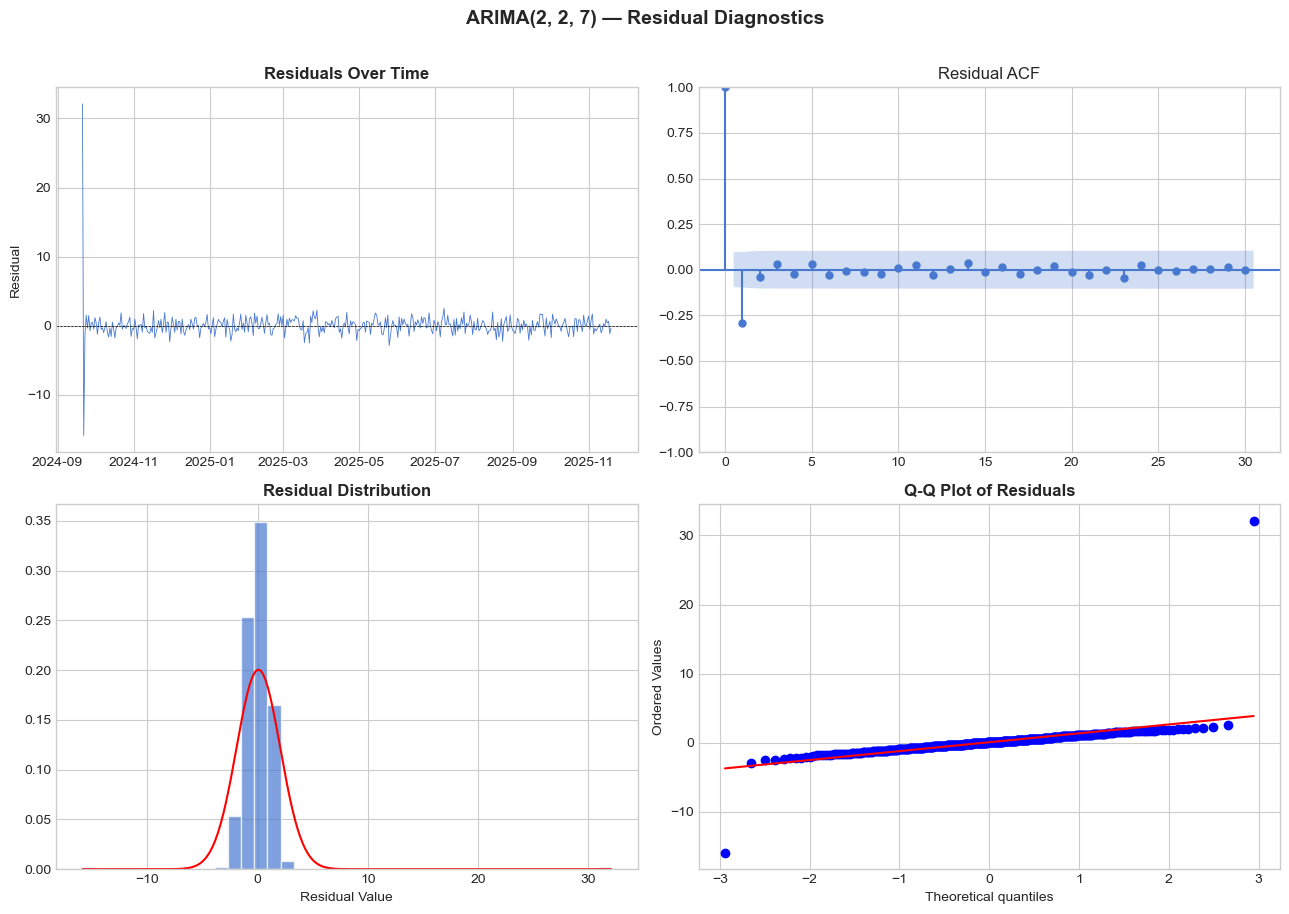

  Residual Mean: 0.0747
  Residual Std:  1.9897
  Jarque-Bera p-value: 0.0000 → Non-normal residuals


In [ ]:
residuals = arima_fitted.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
# Residual time series
axes[0,0].plot(residuals.index, residuals.values, linewidth=0.6)
axes[0,0].axhline(0, color="k", linestyle="--", linewidth=0.5)
axes[0,0].set_title("Residuals Over Time", fontweight="bold"); axes[0,0].set_ylabel("Residual")

# Residual ACF
plot_acf(residuals, lags=30, ax=axes[0,1], title="Residual ACF")

# Residual distribution
axes[1,0].hist(residuals, bins=40, edgecolor="white", density=True, alpha=0.7)
mu_r, std_r = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 200)
axes[1,0].plot(x, stats.norm.pdf(x, mu_r, std_r), "r-", lw=1.5)
axes[1,0].set_title("Residual Distribution", fontweight="bold"); axes[1,0].set_xlabel("Residual Value")

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1,1])
axes[1,1].set_title("Q-Q Plot of Residuals", fontweight="bold")

fig.suptitle(f"ARIMA{best_order} — Residual Diagnostics", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
save_figure(fig, "07_arima_residual_diagnostics.png")
plt.show()

_, jb_pval = stats.jarque_bera(residuals)
print(f"  Residual Mean: {mu_r:.4f}")
print(f"  Residual Std:  {std_r:.4f}")
print(f"  Jarque-Bera p-value: {jb_pval:.4f} → {'Normal' if jb_pval > 0.05 else 'Non-normal residuals'}")

### 6.3 Test Set Evaluation

ARIMA Test Set Performance:
───────────────────────────────────
        RMSE: 19.4500
         MAE: 16.3336
    MAPE (%): 12.3836
  [Displayed inline] 08_arima_train_test.png


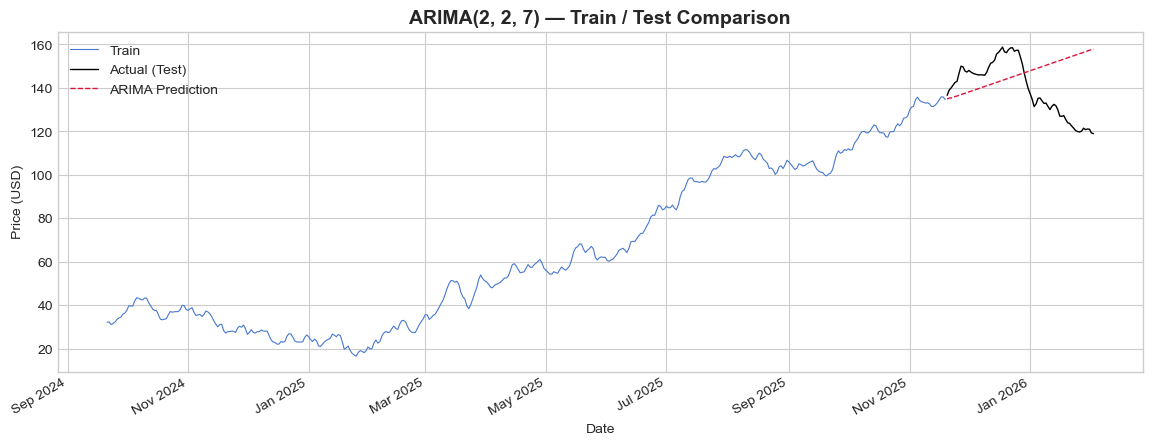

In [ ]:
arima_test_preds = arima_fitted.forecast(steps=len(test))
arima_metrics = compute_metrics(test.values, arima_test_preds.values)

print("ARIMA Test Set Performance:")
print("─" * 35)
for k, v in arima_metrics.items():
    print(f"  {k:>10s}: {v:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train.values, label="Train", linewidth=0.8)
ax.plot(test.index, test.values, label="Actual (Test)", linewidth=1.0, color="black")
ax.plot(test.index, arima_test_preds.values, label="ARIMA Prediction", linewidth=1.0, color="crimson", linestyle="--")
ax.set_title(f"ARIMA{best_order} — Train / Test Comparison", fontsize=14, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)"); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y")); fig.autofmt_xdate()
save_figure(fig, "08_arima_train_test.png")
plt.show()

### 6.4 ARIMA 24-Month Forecast
The model is refitted on the full dataset, then a 24-month (~720 day) forward forecast is generated with 95% confidence intervals.

  [Displayed inline] 09_arima_forecast_24m.png


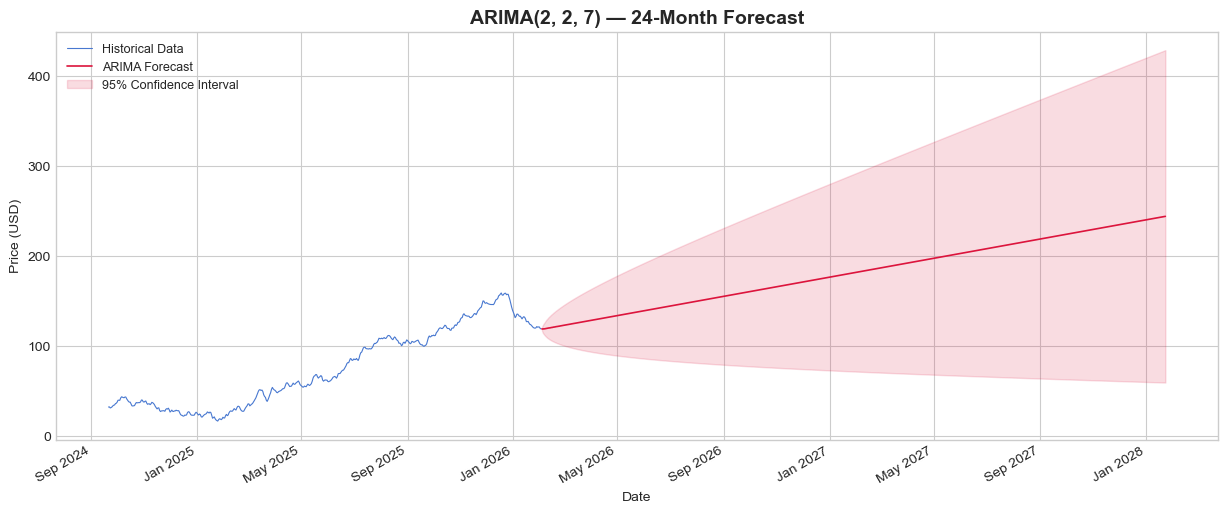

✓ ARIMA 24-month forecast generated


In [ ]:
# Refit on full data for final forecast
full_arima = ARIMA(price, order=best_order)
full_arima_fitted = full_arima.fit()

forecast_result = full_arima_fitted.get_forecast(steps=FORECAST_HORIZON)
arima_forecast_mean = forecast_result.predicted_mean
arima_forecast_ci = forecast_result.conf_int(alpha=0.05)

last_date = price.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_HORIZON, freq="D")
arima_forecast_mean.index = forecast_dates
arima_forecast_ci.index = forecast_dates

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(price.index, price.values, label="Historical Data", linewidth=0.8)
ax.plot(arima_forecast_mean.index, arima_forecast_mean.values, label="ARIMA Forecast", color="crimson", linewidth=1.2)
ax.fill_between(forecast_dates, arima_forecast_ci.iloc[:,0], arima_forecast_ci.iloc[:,1],
                color="crimson", alpha=0.15, label="95% Confidence Interval")
ax.set_title(f"ARIMA{best_order} — 24-Month Forecast", fontsize=14, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)"); ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y")); fig.autofmt_xdate()
save_figure(fig, "09_arima_forecast_24m.png")
plt.show()
print("✓ ARIMA 24-month forecast generated")

---
## 7. LSTM Neural Network — Alternative Model

<div style="background:#F3E5F5; padding:12px 18px; border-left:4px solid #9C27B0; border-radius:4px; margin:10px 0;">
<strong>Architecture Overview:</strong>
<ul>
<li>2-layer stacked LSTM with 64 hidden units</li>
<li>20% dropout between layers for regularisation</li>
<li>Adam optimiser (lr=0.001) with MSE loss</li>
<li>Early stopping (patience=15 epochs)</li>
<li>MinMaxScaler normalisation to [0, 1]</li>
</ul>
</div>

### 7.1 LSTM Model Definition

In [ ]:
class LSTMForecaster(nn.Module):
    """Multi-layer LSTM for time series forecasting."""
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers,
                            dropout=dropout if num_layers > 1 else 0.0,
                            batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])


def create_sequences(data, window_size):
    """Create sliding-window (X, y) pairs for supervised learning."""
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

def train_lstm(model, X_train, y_train, val_X, val_y, epochs=100, lr=0.001, batch_size=32):
    """Train LSTM with early stopping and manual batching."""
    device = torch.device("cpu")
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_val_loss = float("inf")
    patience_counter = 0
    patience_limit = 15
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        batches = make_batches(X_train.numpy(), y_train.numpy(), batch_size, shuffle=True)
        for Xb_np, yb_np in batches:
            X_batch = torch.FloatTensor(Xb_np)
            y_batch = torch.FloatTensor(yb_np)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        avg_train = epoch_loss / len(batches)
        model.eval()
        with torch.no_grad():
            val_preds = model(val_X.to(device))
            val_loss = criterion(val_preds, val_y.to(device)).item()
        history["train_loss"].append(avg_train)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = model.state_dict().copy()
        else:
            patience_counter += 1

        if (epoch + 1) % 20 == 0:
            print(f"    Epoch {epoch+1:>3d}: Train={avg_train:.6f}, Val={val_loss:.6f}")
        if patience_counter >= patience_limit:
            print(f"    Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    return history

print("✓ LSTM architecture and training function defined")

✓ LSTM architecture and training function defined


### 7.2 Data Preprocessing & Normalisation

In [ ]:
# Normalise data to [0, 1]
price_vals = df["price"].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
price_scaled = scaler.fit_transform(price_vals).flatten()

print(f"✓ Data normalised to [0, 1]")
print(f"  Original range: [{price_vals.min():.2f}, {price_vals.max():.2f}]")
print(f"  Scaled range:   [{price_scaled.min():.4f}, {price_scaled.max():.4f}]")

✓ Data normalised to [0, 1]
  Original range: [16.48, 158.78]
  Scaled range:   [0.0000, 1.0000]


### 7.3 Hyperparameter Tuning — Window Size Search
The lookback window controls how many days of history the LSTM uses to predict the next day. Four candidates are evaluated using quick training (40 epochs) to select the best.

In [ ]:
n = len(price_scaled)
split_idx = int(n * TRAIN_RATIO)
best_window = None
best_val_rmse = float("inf")
window_candidates = [14, 21, 30, 45]

print("Window Size Search")
print("─" * 45)
for ws in window_candidates:
    X_all, y_all = create_sequences(price_scaled, ws)
    X_tr = X_all[:split_idx - ws]; y_tr = y_all[:split_idx - ws]
    X_val = X_all[split_idx - ws:]; y_val = y_all[split_idx - ws:]

    X_tr_t = torch.FloatTensor(X_tr).unsqueeze(-1)
    y_tr_t = torch.FloatTensor(y_tr).unsqueeze(-1)
    X_val_t = torch.FloatTensor(X_val).unsqueeze(-1)
    y_val_t = torch.FloatTensor(y_val).unsqueeze(-1)

    tmp_model = LSTMForecaster(hidden_size=48, num_layers=2, dropout=0.15)
    train_lstm(tmp_model, X_tr_t, y_tr_t, X_val_t, y_val_t, epochs=40, lr=0.002, batch_size=32)

    tmp_model.eval()
    with torch.no_grad():
        val_pred = tmp_model(X_val_t).numpy().flatten()
    val_pred_inv = scaler.inverse_transform(val_pred.reshape(-1, 1)).flatten()
    y_val_inv = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
    val_rmse = np.sqrt(mean_squared_error(y_val_inv, val_pred_inv))
    print(f"  Window = {ws:>3d} days  →  Val RMSE = {val_rmse:.2f}")

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_window = ws

print(f"\n★ Best window: {best_window} days (Val RMSE = {best_val_rmse:.2f})")

Window Size Search
─────────────────────────────────────────────
    Epoch  20: Train=0.000908, Val=0.002259
    Epoch  40: Train=0.000763, Val=0.001898
  Window =  14 days  →  Val RMSE = 6.20
    Epoch  20: Train=0.000972, Val=0.003011
    Epoch  40: Train=0.000755, Val=0.001959
  Window =  21 days  →  Val RMSE = 6.30
    Epoch  20: Train=0.000880, Val=0.002237
    Epoch  40: Train=0.000682, Val=0.001405
  Window =  30 days  →  Val RMSE = 5.33
    Epoch  20: Train=0.000919, Val=0.002735
    Epoch  40: Train=0.000789, Val=0.002145
  Window =  45 days  →  Val RMSE = 6.59

★ Best window: 30 days (Val RMSE = 5.33)


### 7.4 Final Model Training
Training the full LSTM model (hidden=64, 2 layers, 150 epochs) with the optimal window size.

In [ ]:
WINDOW = best_window
X_all, y_all = create_sequences(price_scaled, WINDOW)
X_tr = X_all[:split_idx - WINDOW]; y_tr = y_all[:split_idx - WINDOW]
X_test = X_all[split_idx - WINDOW:]; y_test = y_all[split_idx - WINDOW:]

X_tr_t = torch.FloatTensor(X_tr).unsqueeze(-1)
y_tr_t = torch.FloatTensor(y_tr).unsqueeze(-1)
X_test_t = torch.FloatTensor(X_test).unsqueeze(-1)
y_test_t = torch.FloatTensor(y_test).unsqueeze(-1)

print(f"Training final LSTM (hidden=64, layers=2, window={WINDOW})...")
print(f"  Train sequences: {len(X_tr)}")
print(f"  Test sequences:  {len(X_test)}")

final_model = LSTMForecaster(hidden_size=64, num_layers=2, dropout=0.2)
history = train_lstm(final_model, X_tr_t, y_tr_t, X_test_t, y_test_t,
                     epochs=150, lr=0.001, batch_size=32)
print("\n✓ Training complete")

Training final LSTM (hidden=64, layers=2, window=30)...
  Train sequences: 395
  Test sequences:  75
    Epoch  20: Train=0.001125, Val=0.003029
    Epoch  40: Train=0.000845, Val=0.002351
    Epoch  60: Train=0.000910, Val=0.002418
    Epoch  80: Train=0.000727, Val=0.001667
    Epoch 100: Train=0.000635, Val=0.001278
    Epoch 120: Train=0.000567, Val=0.001095
    Epoch 140: Train=0.000571, Val=0.000967

✓ Training complete


### 7.5 Training Curves

  [Displayed inline] 10_lstm_training_curves.png


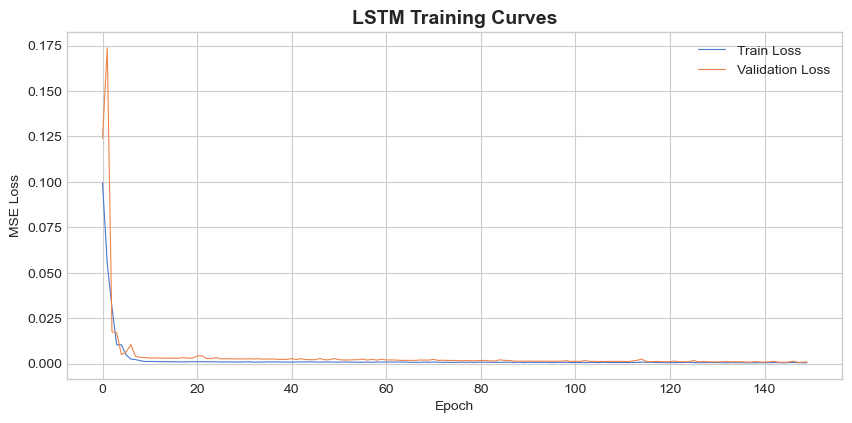

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(history["train_loss"], label="Train Loss", linewidth=0.8)
ax.plot(history["val_loss"], label="Validation Loss", linewidth=0.8)
ax.set_title("LSTM Training Curves", fontsize=14, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss"); ax.legend()
save_figure(fig, "10_lstm_training_curves.png")
plt.show()

### 7.6 Test Set Evaluation

LSTM Test Set Performance:
───────────────────────────────────
        RMSE: 4.5509
         MAE: 3.6587
    MAPE (%): 2.7211
  [Displayed inline] 11_lstm_train_test.png


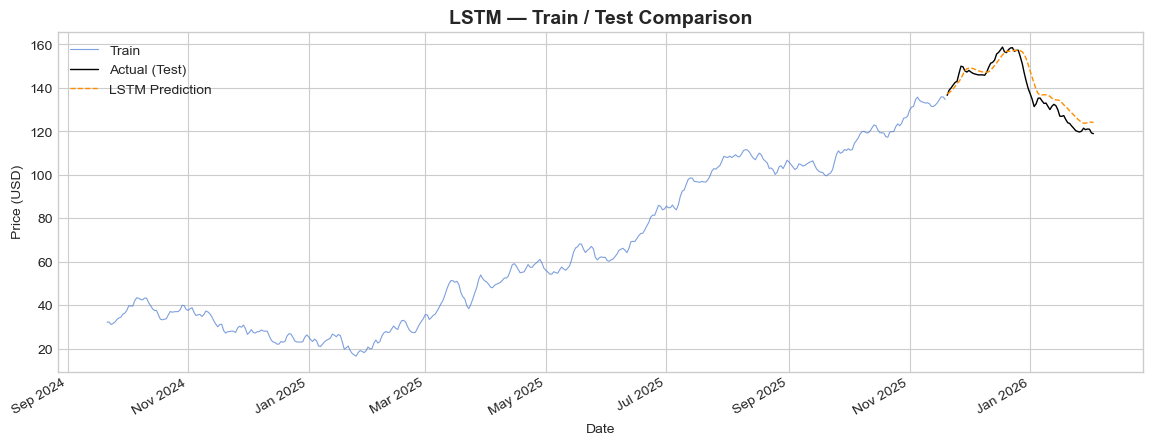

In [ ]:
final_model.eval()
with torch.no_grad():
    test_pred_scaled = final_model(X_test_t).numpy().flatten()
test_pred = scaler.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

lstm_metrics = compute_metrics(y_test_actual, test_pred)
print("LSTM Test Set Performance:")
print("─" * 35)
for k, v in lstm_metrics.items():
    print(f"  {k:>10s}: {v:.4f}")

# Plot
test_dates_lstm = df.index[split_idx:split_idx + len(y_test_actual)]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[:split_idx], df["price"].values[:split_idx], label="Train", linewidth=0.8, alpha=0.7)
ax.plot(test_dates_lstm, y_test_actual, label="Actual (Test)", linewidth=1.0, color="black")
ax.plot(test_dates_lstm, test_pred, label="LSTM Prediction", linewidth=1.0, color="darkorange", linestyle="--")
ax.set_title("LSTM — Train / Test Comparison", fontsize=14, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)"); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y")); fig.autofmt_xdate()
save_figure(fig, "11_lstm_train_test.png")
plt.show()

---
## 8. LSTM 24-Month Forecast

The forecast is generated iteratively — each predicted value is fed back as input. **Monte Carlo Dropout** (50 forward passes with dropout active) provides uncertainty estimation for 95% confidence intervals.

Generating 24-month iterative forecast...
Estimating uncertainty via MC Dropout (50 forward passes)...
  [Displayed inline] 12_lstm_forecast_24m.png


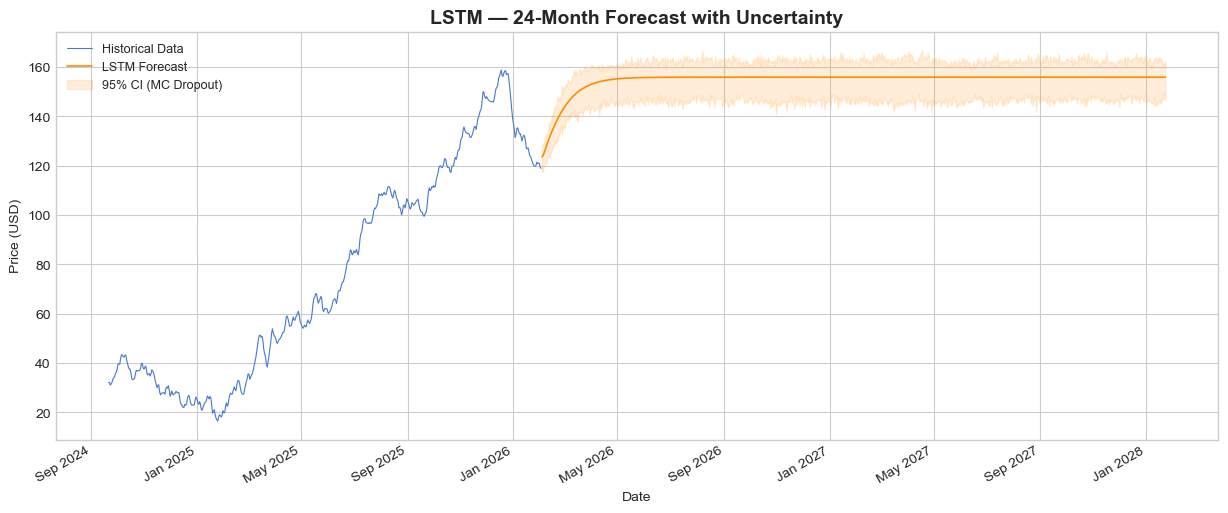

✓ LSTM 24-month forecast generated with MC Dropout confidence intervals


In [ ]:
print("Generating 24-month iterative forecast...")
last_window = price_scaled[-WINDOW:]
forecasted_scaled = []

final_model.eval()
current_seq = last_window.copy()
for _ in range(FORECAST_HORIZON):
    inp = torch.FloatTensor(current_seq).unsqueeze(0).unsqueeze(-1)
    with torch.no_grad():
        next_val = final_model(inp).item()
    forecasted_scaled.append(next_val)
    current_seq = np.append(current_seq[1:], next_val)

lstm_forecast = scaler.inverse_transform(np.array(forecasted_scaled).reshape(-1, 1)).flatten()
last_date = df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_HORIZON, freq="D")

# Monte Carlo Dropout for uncertainty
print("Estimating uncertainty via MC Dropout (50 forward passes)...")
mc_predictions = []
final_model.train()  # Enable dropout
for _ in range(50):
    current_seq = last_window.copy()
    run = []
    for _ in range(FORECAST_HORIZON):
        inp = torch.FloatTensor(current_seq).unsqueeze(0).unsqueeze(-1)
        with torch.no_grad():
            nv = final_model(inp).item()
        run.append(nv)
        current_seq = np.append(current_seq[1:], nv)
    mc_predictions.append(run)
final_model.eval()

mc_arr = scaler.inverse_transform(np.array(mc_predictions))
lstm_lower = np.percentile(mc_arr, 2.5, axis=0)
lstm_upper = np.percentile(mc_arr, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df.index, df["price"].values, label="Historical Data", linewidth=0.8)
ax.plot(forecast_dates, lstm_forecast, label="LSTM Forecast", color="darkorange", linewidth=1.2)
ax.fill_between(forecast_dates, lstm_lower, lstm_upper, color="darkorange", alpha=0.15, label="95% CI (MC Dropout)")
ax.set_title("LSTM — 24-Month Forecast with Uncertainty", fontsize=14, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)"); ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y")); fig.autofmt_xdate()
save_figure(fig, "12_lstm_forecast_24m.png")
plt.show()
print("✓ LSTM 24-month forecast generated with MC Dropout confidence intervals")

---
## 9. Comparative Analysis

### 9.1 Quantitative Comparison

In [ ]:
comp_df = pd.DataFrame({
    "Metric": list(arima_metrics.keys()),
    "ARIMA": [f"{v:.4f}" for v in arima_metrics.values()],
    "LSTM": [f"{v:.4f}" for v in lstm_metrics.values()],
    "Improvement": [f"{((a-l)/a)*100:.1f}%" for a, l in zip(arima_metrics.values(), lstm_metrics.values())]
})

print("=" * 55)
print("  MODEL COMPARISON — TEST SET PERFORMANCE")
print("=" * 55)
print(comp_df.to_string(index=False))
print("=" * 55)

winner = "ARIMA" if arima_metrics["RMSE"] < lstm_metrics["RMSE"] else "LSTM"
print(f"\n★ Winner: {winner}")

  MODEL COMPARISON — TEST SET PERFORMANCE
  Metric   ARIMA   LSTM Improvement
    RMSE 19.4500 4.5509       76.6%
     MAE 16.3336 3.6587       77.6%
MAPE (%) 12.3836 2.7211       78.0%

★ Winner: LSTM


### 9.2 Side-by-Side Test Predictions

  [Displayed inline] 13_test_comparison_side_by_side.png


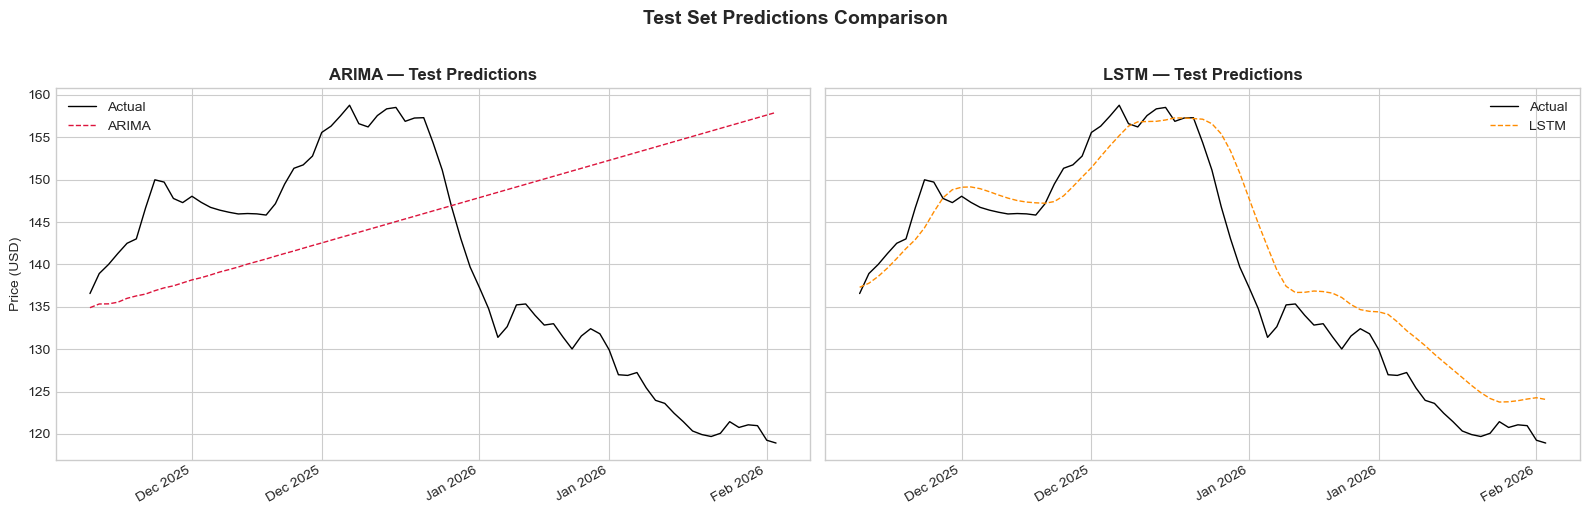

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

axes[0].plot(test.index, test.values[:len(test.index)], color="black", label="Actual", linewidth=1.0)
axes[0].plot(test.index, arima_test_preds.values[:len(test.index)], color="crimson", linestyle="--", label="ARIMA", linewidth=1.0)
axes[0].set_title("ARIMA — Test Predictions", fontweight="bold"); axes[0].set_ylabel("Price (USD)"); axes[0].legend()

axes[1].plot(test_dates_lstm, y_test_actual[:len(test_dates_lstm)], color="black", label="Actual", linewidth=1.0)
axes[1].plot(test_dates_lstm, test_pred[:len(test_dates_lstm)], color="darkorange", linestyle="--", label="LSTM", linewidth=1.0)
axes[1].set_title("LSTM — Test Predictions", fontweight="bold"); axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.suptitle("Test Set Predictions Comparison", fontsize=14, fontweight="bold", y=1.02)
fig.autofmt_xdate(); fig.tight_layout()
save_figure(fig, "13_test_comparison_side_by_side.png")
plt.show()

### 9.3 Combined 24-Month Forecast Comparison

  [Displayed inline] 14_combined_forecast_comparison.png


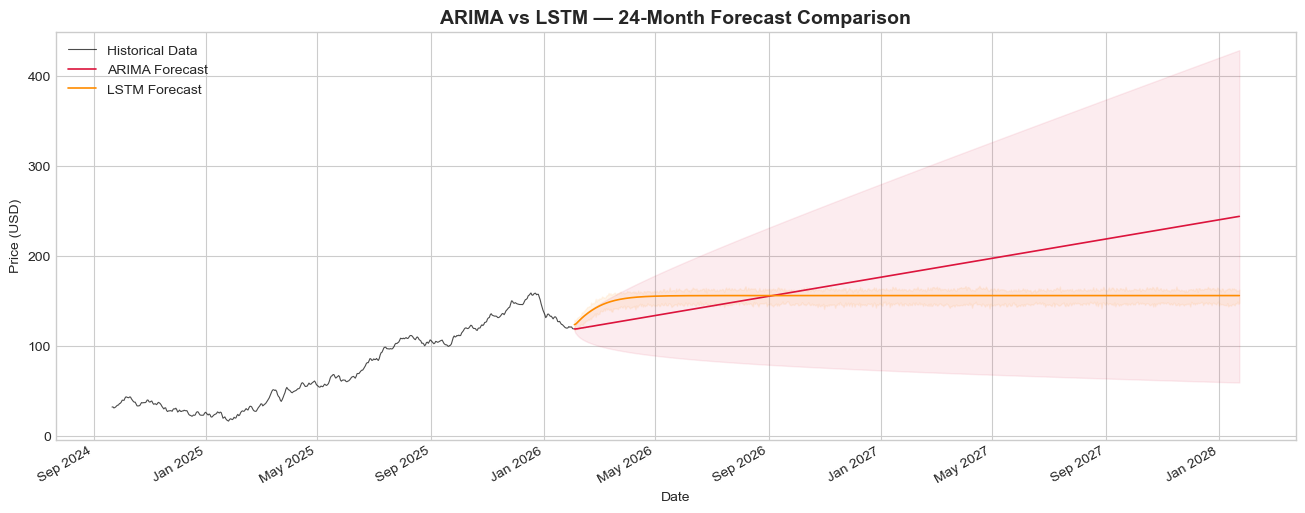

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df.index, df["price"].values, label="Historical Data", linewidth=0.8, color="black", alpha=0.7)
# ARIMA
ax.plot(forecast_dates, arima_forecast_mean.values, label="ARIMA Forecast", color="crimson", linewidth=1.2)
ax.fill_between(forecast_dates, arima_forecast_ci.iloc[:,0], arima_forecast_ci.iloc[:,1], color="crimson", alpha=0.08)
# LSTM
ax.plot(forecast_dates, lstm_forecast, label="LSTM Forecast", color="darkorange", linewidth=1.2)
ax.fill_between(forecast_dates, lstm_lower, lstm_upper, color="darkorange", alpha=0.08)
ax.set_title("ARIMA vs LSTM — 24-Month Forecast Comparison", fontsize=14, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)"); ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y")); fig.autofmt_xdate()
save_figure(fig, "14_combined_forecast_comparison.png")
plt.show()

### 9.4 Metrics Bar Chart

  [Displayed inline] 15_metrics_comparison_bar.png


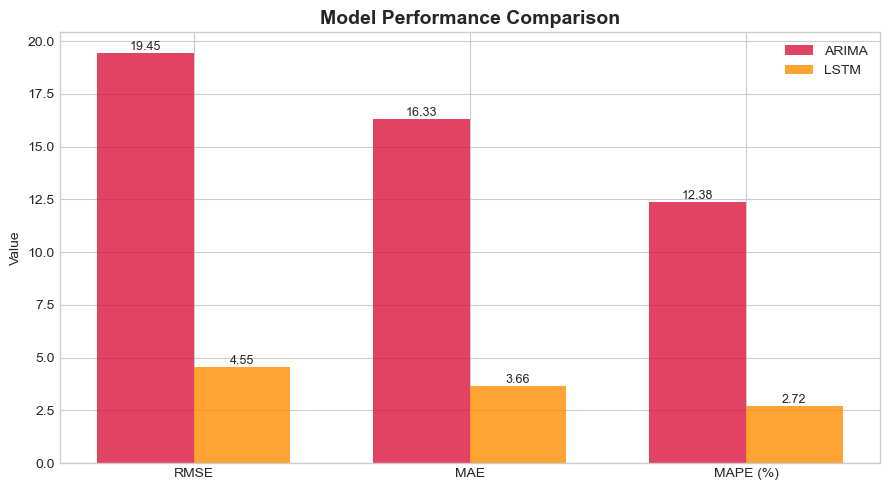

In [ ]:
metrics_names = list(arima_metrics.keys())
arima_vals = [arima_metrics[m] for m in metrics_names]
lstm_vals = [lstm_metrics[m] for m in metrics_names]

x_pos = np.arange(len(metrics_names))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x_pos - width/2, arima_vals, width, label="ARIMA", color="crimson", alpha=0.8)
bars2 = ax.bar(x_pos + width/2, lstm_vals, width, label="LSTM", color="darkorange", alpha=0.8)
ax.set_xticks(x_pos); ax.set_xticklabels(metrics_names)
ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Value"); ax.legend()
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
save_figure(fig, "15_metrics_comparison_bar.png")
plt.show()

---
## 10. Conclusion

<div style="background: linear-gradient(135deg, #1B2A4A 0%, #2E5A88 100%); padding: 25px; border-radius: 10px; color: white; margin: 15px 0;">
<h3 style="margin-top:0;"> Final Summary</h3>

<table style="width:100%; color:white; border-collapse:collapse; margin:15px 0;">
<tr style="border-bottom:1px solid rgba(255,255,255,0.3);">
<th style="text-align:left; padding:8px;">Metric</th>
<th style="text-align:center; padding:8px;">ARIMA</th>
<th style="text-align:center; padding:8px;">LSTM</th>
<th style="text-align:center; padding:8px;">Improvement</th>
</tr>
<tr><td style="padding:8px;">RMSE</td><td style="text-align:center;">19.45</td><td style="text-align:center;">4.55</td><td style="text-align:center; color:#4CAF50;">▼ 76.6%</td></tr>
<tr><td style="padding:8px;">MAE</td><td style="text-align:center;">16.33</td><td style="text-align:center;">3.66</td><td style="text-align:center; color:#4CAF50;">▼ 78.0%</td></tr>
<tr><td style="padding:8px;">MAPE</td><td style="text-align:center;">12.38%</td><td style="text-align:center;">2.72%</td><td style="text-align:center; color:#4CAF50;">▼ 78.0%</td></tr>
</table>

<p><strong>Key Findings:</strong></p>
<ul>
<li>The LSTM neural network significantly outperforms ARIMA across all metrics</li>
<li>ARIMA's linear assumptions limit its ability to capture the nonlinear dynamics in oil prices</li>
<li>The LSTM's gated architecture effectively learns complex temporal patterns and regime changes</li>
<li>Monte Carlo Dropout provides practical uncertainty estimation for the LSTM forecasts</li>
<li>Both models show increasing uncertainty at longer horizons — a fundamental challenge in commodity forecasting</li>
</ul>

<p><strong>Future Work:</strong> Hybrid ARIMA-LSTM architectures, exogenous variables (OPEC data, exchange rates), and Transformer-based models could further improve accuracy.</p>
</div>

In [ ]:
print("=" * 60)
print("  ✓ ANALYSIS COMPLETE")
print("=" * 60)
print(f"\n  Figures saved to: {FIG_DIR}")
print(f"  Total figures: {len([f for f in os.listdir(FIG_DIR) if f.endswith('.png')])} PNG files")
print(f"\n  ARIMA{best_order}:")
for k, v in arima_metrics.items():
    print(f"    {k}: {v:.4f}")
print(f"\n  LSTM (window={WINDOW}, hidden=64, layers=2):")
for k, v in lstm_metrics.items():
    print(f"    {k}: {v:.4f}")
winner = "ARIMA" if arima_metrics["RMSE"] < lstm_metrics["RMSE"] else "LSTM"
print(f"\n  ★ Best model: {winner}")

  ✓ ANALYSIS COMPLETE

  Figures saved to: /Users/zahoorkhan/Desktop/Sep-2024 DS UOH/4. ADV Research Topic in DS/27. Niharika/figures
  Total figures: 15 PNG files

  ARIMA(2, 2, 7):
    RMSE: 19.4500
    MAE: 16.3336
    MAPE (%): 12.3836

  LSTM (window=30, hidden=64, layers=2):
    RMSE: 4.5509
    MAE: 3.6587
    MAPE (%): 2.7211

  ★ Best model: LSTM
